# flexible neutrino oscillation simulator 

(c) Isabel Goos, Yael Deniz

15/07/2026



## loading packages

In [1]:
using Pkg
cd(@__DIR__)
Pkg.activate("../")
ParamFile = "../config/testparam.csv" # 1D Earth/Mars/Moon models are defined

include("../src/commonBatchs.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")

using .commonBatchs, .planet1D, .GeoPoints

  Activating project at `~/Documents/Github/flexOPT`


In [2]:
using CairoMakie

In [3]:

#Pkg.add("Plots")
#Pkg.add("LaTeXStrings")
using Plots
using LaTeXStrings

In [4]:
include("../src/neutrinoFlux.jl")
using .neutrinoFlux

## constants

### binning of energies (binned logarithmically) and cos \theta (binned linearly)

In [5]:
numberEnergyBins = 100
minEnergy = 1.0
maxEnergy = 100.0

numberAngleBins = 100
mincosθ = -1
maxcosθ = 0

binningEnergy = (numberEnergyBins=numberEnergyBins, minEnergy=minEnergy, maxEnergy=maxEnergy)
binningcosθ = (numberAngleBins =numberAngleBins , mincosθ=mincosθ, maxcosθ=maxcosθ)
binning = (energy=binningEnergy, cosθ= binningcosθ)
# makeArrayBins(binningEnergy; option="linear") something like this should be made

# computeFlux(binning) # honda/daemon is already decided by DEFAULT_FLUX_TABLE; 

# maybe computeFlux(binning::this binnning Tuple)  = computeFlux(makeArrayBins(binningEnergy; option="log"))
# or for the custom arrays (energy array, cosarray ) <- bigger than binningArray (6 components)

(energy = (numberEnergyBins = 100, minEnergy = 1.0, maxEnergy = 100.0), cosθ = (numberAngleBins = 100, mincosθ = -1, maxcosθ = 0))

# configurations (Earth model, flux model and detector model)

The back ground 1D Earth model should be (unfortunately) controlled by planet1D.jl with ParamFile = "../config/testparam.csv",
which I really need to change like GeoPoints.jl where I used DEFAULT_PLANET thing. 
Until that update, please just inclue testparam.csv and use whatever your favourite Earth models


In [8]:
#change_default_flux!(:Honda)

In [9]:
set_default_planet!(:Earth) # :Earth applies WGS84 (otherwise use :SphericalEarth

Ellipsoid(Earth)

In [10]:
detectorPoint = GeoPoint(36.296761,15.978403;alt=-3500.0) # lat, lon with altitude in metre

GeoPoint(36.296761, 15.978403, -3500.0, [4.9450275343241915e6, 1.4159468120344188e6, 3.752709763576236e6], 6.367184091839597e6)

In [11]:
# cutting the Earth based on the detector point and the centre of the Earth
Δx = 5.e3 # in metre
Δz = 5.e3

altMax = 6400.e3 # in metre
altMin = -6400.e3 # in metre

horizontalMax = 6400.e3 # in metre 
horizontalMin =-6400.e3 # in metre

boxGrids=constructLocalBox(detectorPoint,Δx,Δz,altMin,altMax,horizontalMin,horizontalMax;centreOption= "centreOfPlanet")

centreOption = "centreOfPlanet"


(allGridsInGeoPoints = GeoPoint[GeoPoint(-35.956926118895126, -155.85612159732312, 2.6801718282421906e6, [-6.696349646292082e6, -3.0015784178204727e6, -5.298058929105852e6], 9.05096679918781e6) GeoPoint(-35.955355616939705, -155.82857866727764, 2.676636420145778e6, [-6.692427760336247e6, -3.003684839486892e6, -5.295782572738174e6], 9.04743195608566e6) … GeoPoint(3.355958496030118, -68.29876611728461, 2.6693677710241335e6, [3.339756514689156e6, -8.391911462186964e6, 527137.0157809046], 9.04743195608566e6) GeoPoint(3.3691428617270907, -68.28059833278513, 2.672903186865249e6, [3.3436784006449906e6, -8.394017883853383e6, 529413.3721485821], 9.05096679918781e6); GeoPoint(-35.95859097714301, -155.88366564861224, 2.676637565735831e6, [-6.695040009086751e6, -2.997127013015131e6, -5.296196176935165e6], 9.04743195608566e6) GeoPoint(-35.95702682798062, -155.85612159732312, 2.673100778260053e6, [-6.691118123130917e6, -2.99923343468155e6, -5.293919820567488e6], 9.043895731375942e6) … GeoPoint(3.369

In [12]:
seismicModel=lazyProduceOrLoad("seismicModel2Dsparse",getParamsWithoutTopo,boxGrids.allGridsInGeoPoints,boxGrids.effectiveRadii)

Computing seismicModel2Dsparse


(ρ = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Vpv = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Vph = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Vsv = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Vsh = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Qμ = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Qκ = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], QμPower = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], QκPower = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], η = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])

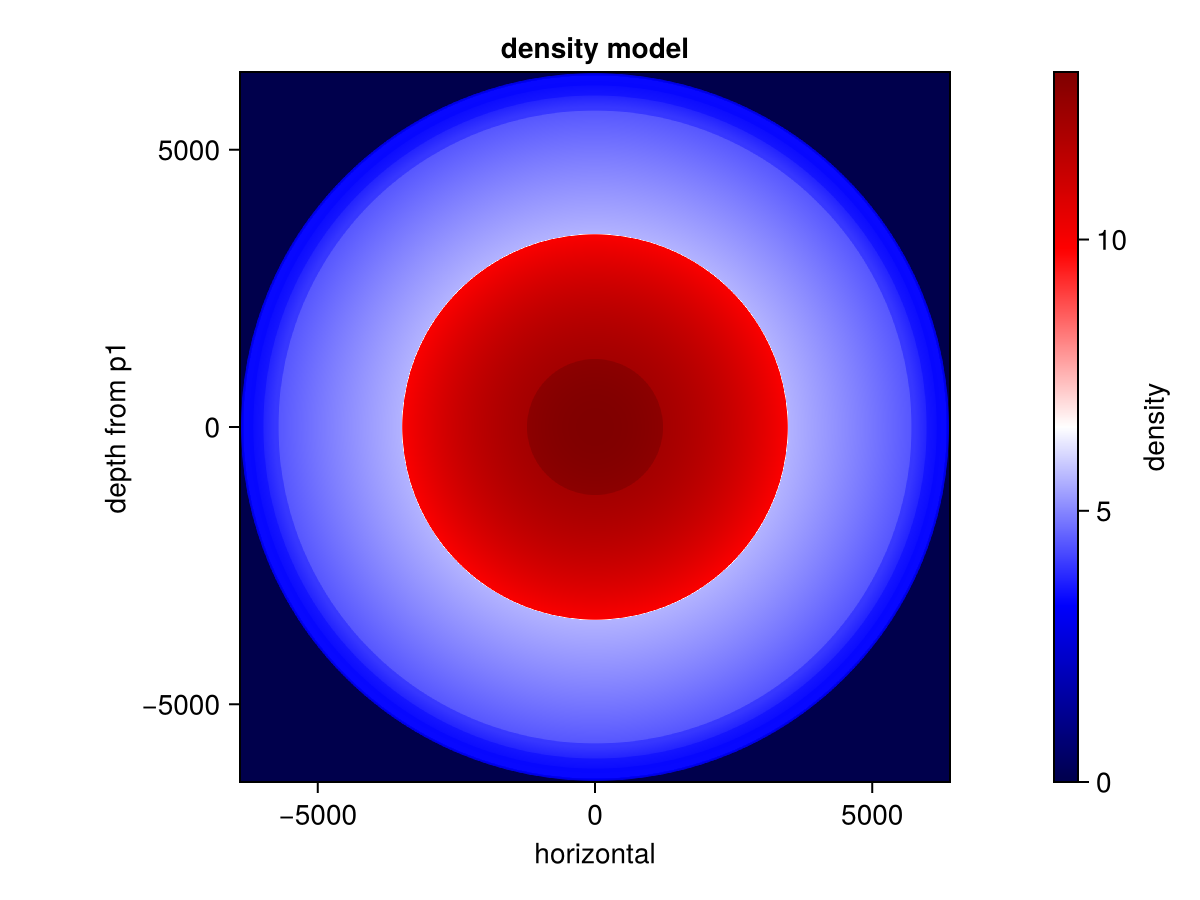

In [13]:

Nx,Nz=size(seismicModel.ρ)
xvals = [p.xz[1] for p in boxGrids.allGridsInCartesian[:,1]]*1.e-3
zvals = [p.xz[2] for p in boxGrids.allGridsInCartesian[1,:]]*1.e-3
fig, ax, hm = CairoMakie.heatmap(
    #topo.x,topo.y,topo.z';
    #collect((0:1:(Nx-1)).*Δx).*1.e-3,(collect(0:1:(Nz-1)).*Δz.+altMin).*1.e-3, seismicModel.ρ;
    xvals, zvals, seismicModel.ρ;
    colormap = :seismic,
    #colorrange=(0,4),
    axis = (aspect = DataAspect(), xlabel = "horizontal", ylabel = "depth from p1", title = "density model")
)
Colorbar(fig[1,2], hm, label="density")
fig

## GeoPoints to make 

### here, i would like the users to decide which flux model to be used


## neutrino flux (completely new!!)


In [14]:
energies = logrange(minEnergy, maxEnergy, numberEnergyBins)
# read the neutrino-flux table nuflux.csv given in .../Neutrino-Flux/data
bin_centers, flux_νe_interp, flux_νμ_interp, flux_antiνe_interp, flux_antiνμ_interp, energies, flux_νe, flux_νμ, flux_antiνe, flux_antiνμ = read_neutrino_flux_table("nuflux", numberEnergyBins, numberAngleBins, false; data_dir="../dataInput/neutrinoFluxData/")


([1.023523326553919, 1.0722597633036501, 1.123345672533615, 1.1768322310338035, 1.2328659902844266, 1.291551628855773, 1.3530333735721378, 1.417467078982789, 1.4849481203058914, 1.5556788775322496  …  64.28061744414097, 67.34128242022126, 70.5479171060351, 73.90701162947938, 77.42605638930605, 81.11305354873531, 84.9755167680668, 89.02142494927836, 93.26026903242344, 97.70107471261511], [126.88362621513429 126.88362621513429 … 71.91475609254222 71.31160025885342; 112.60555375139846 112.60555375139846 … 62.76445029750061 62.22621223011901; … ; 0.00022338324999782245 0.00022338324999782245 … 1.5405550706562013e-5 1.5234126738576753e-5; 0.0001911248182553584 0.0001911248182553584 … 1.3205846126267646e-5 1.3060796619282006e-5], [206.9910269665506 206.9910269665506 … 168.43390615639078 167.97919075040974; 183.01015279626722 183.01015279626722 … 148.06698376438334 147.6627381150657; … ; 0.0006904593911871498 0.0006904593911871498 … 0.00027336571337727205 0.0002719737383124423; 0.000603080684

In [15]:
 # otherwise it will be daemon flux; this thing should be given in neutrinoFlux/cofig.jl

In [16]:
# neutrino fluxes look good
# (comparing with Figure 3 in arXiv:1502.03916;
# there are slight differences, especially at low energies, because
# daemonflux is a bit different from honda)

numberEnergyBinSegments = numberEnergyBins - 1 

p1 = plot(energies, (energies.^3) .* sum(flux_νe,     dims=2) ./ numberEnergyBinSegments, label=L"$\nu_e$", 
          xaxis=:log, yaxis=:log, legend=:bottom,
          xlabel="E/GeV", ylabel=L"$\phi \times E_\nu^3$ /(m$^{-2}$s$^{-1}$sr$^{-1}$GeV$^{2}$")
plot!(p1, energies, (energies.^3) .* sum(flux_νμ,     dims=2) ./ numberEnergyBinSegments, label=L"$\nu_\mu$")
plot!(p1, energies, (energies.^3) .* sum(flux_antiνe, dims=2) ./ numberEnergyBinSegments, label=L"$\bar{\nu}_e$")
plot!(p1, energies, (energies.^3) .* sum(flux_antiνμ, dims=2) ./ numberEnergyBinSegments, label=L"$\bar{\nu}_\mu$")


UndefVarError: UndefVarError: `plot` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.
Hint: a global variable of this name also exists in MakieCore.
    - Also exported by Makie.
    - Also exported by CairoMakie.
Hint: a global variable of this name also exists in GR.jlgr.
    - Also exported by GR.
Hint: a global variable of this name also exists in GMT.
Hint: a global variable of this name also exists in RecipesBase.
    - Also exported by Plots.

In [17]:
# linear interpolation on the flux dimension vs. correctly interpolated flux (in log of flux) 
# but anyways, it works (< 0.2%)

# plot the differences between the original and the interpolated fluxes
# to make sure that the interpolation is working correctly
# -> for the original flux we take the mean values
flux_νe_original     = 0.5 .* (sum(flux_νe,     dims=2)[1:end-1] .+ sum(flux_νe, dims=2)[2:end])
flux_νμ_original     = 0.5 .* (sum(flux_νμ,     dims=2)[1:end-1] .+ sum(flux_νμ, dims=2)[2:end])
flux_antiνe_original = 0.5 .* (sum(flux_antiνe, dims=2)[1:end-1] .+ sum(flux_antiνe, dims=2)[2:end])
flux_antiνμ_original = 0.5 .* (sum(flux_antiνμ, dims=2)[1:end-1] .+ sum(flux_antiνμ, dims=2)[2:end])
p2 = plot(bin_centers, 100 .* (sum(flux_νe_interp, dims=2) .- flux_νe_original) ./ flux_νe_original, 
          label=L"$\nu_e$", xlabel="E/GeV", ylabel="100 * (original - interpolation) / interpolation")
plot!(p2, bin_centers, 100 .* (sum(flux_νμ_interp,     dims=2) .- flux_νμ_original)     ./ flux_νμ_original,     label=L"$\nu_\mu$") 
plot!(p2, bin_centers, 100 .* (sum(flux_antiνe_interp, dims=2) .- flux_antiνe_original) ./ flux_antiνe_original, label=L"$\bar{\nu}_e$") 
plot!(p2, bin_centers, 100 .* (sum(flux_antiνμ_interp, dims=2) .- flux_antiνμ_original) ./ flux_antiνμ_original, label=L"$\bar{\nu}_\mu$") 


UndefVarError: UndefVarError: `plot` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.
Hint: a global variable of this name also exists in MakieCore.
    - Also exported by Makie.
    - Also exported by CairoMakie.
Hint: a global variable of this name also exists in GR.jlgr.
    - Also exported by GR.
Hint: a global variable of this name also exists in GMT.
Hint: a global variable of this name also exists in RecipesBase.
    - Also exported by Plots.

In [18]:
size(flux_νe)

(100, 100)

# i don't touch the pb of reverse(')

In [19]:

# This is what we need to compute the interacting events!:
# TO-DO: put this computation in the function, no user should be doing this XD
flux_νe = reverse(flux_νe', dims=1)
flux_νμ = reverse(flux_νμ', dims=1)
flux_antiνe = reverse(flux_antiνe', dims=1)
flux_antiνμ = reverse(flux_antiνμ', dims=1)

100×100 Matrix{Float64}:
 156.83  137.63  120.78  105.86  …  0.00019219  0.00016589  0.00014319
 157.47  138.2   121.29  106.32     0.00019341  0.00016695  0.00014411
 158.11  138.77  121.8   106.78     0.00019463  0.00016801  0.00014502
 158.75  139.35  122.32  107.23     0.00019585  0.00016906  0.00014594
 159.39  139.92  122.83  107.69     0.00019706  0.00017012  0.00014686
 160.0   140.47  123.32  108.12  …  0.00019829  0.00017118  0.00014778
 160.59  140.99  123.79  108.54     0.00019951  0.00017225  0.00014871
 161.17  141.51  124.25  108.96     0.00020074  0.00017331  0.00014963
 161.76  142.04  124.72  109.38     0.00020197  0.00017438  0.00015056
 162.34  142.56  125.19  109.8      0.0002032   0.00017545  0.00015149
   ⋮                             ⋱                          
 212.02  187.69  166.16  146.97     0.00053731  0.00046718  0.00040621
 212.32  187.97  166.41  147.2      0.00055184  0.00047984  0.00041723
 212.62  188.24  166.66  147.43     0.00056637  0.0004925   0.

In [21]:
# neutrino oscillation probabilities look good
# TO-DO: Paνe2aντ deserves some attention → do a difference with OscProb!
minX, maxX, nX = -6500e3, 6500e3, 521
n_angles  = 100
n_pts     = 100
zposition = 2.5e3
energy_min = 1.0
energy_max = 100.0
energy_max = 40.0
osc_probs_nu, osc_probs_antinu = Neutrino_Oscillations.produce_neutrino_oscillation_probabilities(minX, maxX, nX, n_angles, n_pts, zposition, energy_min=energy_min, energy_max=energy_max)
# neutrinos, NMO
Pνe2νe = osc_probs_nu[:, :, 1, 1]' 
Pνe2νμ = osc_probs_nu[:, :, 1, 2]' 
Pνe2ντ = osc_probs_nu[:, :, 1, 3]' 
Pνμ2νe = osc_probs_nu[:, :, 2, 1]' 
Pνμ2νμ = osc_probs_nu[:, :, 2, 2]' 
Pνμ2ντ = osc_probs_nu[:, :, 2, 3]' 
# antineutrinos, NMO
Paνe2aνe = osc_probs_antinu[:, :, 1, 1]' 
Paνe2aνμ = osc_probs_antinu[:, :, 1, 2]' 
Paνe2aντ = osc_probs_antinu[:, :, 1, 3]' 
Paνμ2aνe = osc_probs_antinu[:, :, 2, 1]' 
Paνμ2aνμ = osc_probs_antinu[:, :, 2, 2]' 
Paνμ2aντ = osc_probs_antinu[:, :, 2, 3]' 

# plots for neutrinos, NMO
angles = range(-1, 0, length=100)
titles = (
    L"P($\nu_e \rightarrow \nu_e$)", L"P($\nu_e \rightarrow \nu_\mu$)", L"P($\nu_e \rightarrow \nu_\tau$)",
    L"P($\nu_\mu \rightarrow \nu_e$)", L"P($\nu_\mu \rightarrow \nu_\mu$)", L"P($\nu_\mu \rightarrow \nu_\tau$)"
)
all_probs = (
    Pνe2νe, Pνe2νμ, Pνe2ντ,
    Pνμ2νe, Pνμ2νμ, Pνμ2ντ
)
plot_list = []
for idx in 1:6
    # determine grid positions for labels
    is_bottom_row = idx > 3
    is_left_column = (idx == 1 || idx == 4)
    is_right_column = (idx ==3 || idx == 6)
    p = heatmap(
        energies, angles, all_probs[idx],              
        title = titles[idx],
        xlabel = is_bottom_row ? "Energy/GeV" : "",
        ylabel = is_left_column ? L"\cos\theta" : "",
        colorbar_title = is_right_column ? "Oscillation probability" : "",
        xscale = :log10,
        clim = (0, 1),
        cmap = :viridis
    )
    push!(plot_list, p)
end
final_plot = plot(
    plot_list..., 
    layout = (2, 3), 
    size = (1000, 400), 
    margin = 1Plots.mm,
)

# plots for antineutrinos, NMO
titles = (
    L"P($\bar{\nu}_e \rightarrow \bar{\nu}_e$)", L"P($\bar{\nu}_e \rightarrow \bar{\nu}_\mu$)", L"P($\bar{\nu}_e \rightarrow \bar{\nu}_\tau$)",
    L"P($\bar{\nu}_\mu \rightarrow \bar{\nu}_e$)", L"P($\bar{\nu}_\mu \rightarrow \bar{\nu}_\mu$)", L"P($\bar{\nu}_\mu \rightarrow \bar{nu}_\tau$)"
)
all_probs = (
    Paνe2aνe, Paνe2aνμ, Paνe2aντ,
    Paνμ2aνe, Paνμ2aνμ, Paνμ2aντ
)
plot_list = []
for idx in 1:6
    # determine grid positions for labels
    is_bottom_row = idx > 3
    is_left_column = (idx == 1 || idx == 4)
    is_right_column = (idx ==3 || idx == 6)
    p = heatmap(
        energies, angles, all_probs[idx],              
        title = titles[idx],
        xlabel = is_bottom_row ? "Energy/GeV" : "",
        ylabel = is_left_column ? L"\cos\theta" : "",
        colorbar_title = is_right_column ? "Oscillation probability" : "",
        xscale = :log10,
        clim = (0, 1),
        cmap = :viridis
    )
    push!(plot_list, p)
end
final_plot = plot(
    plot_list..., 
    layout = (2, 3), 
    size = (1000, 400), 
    margin = 1Plots.mm
)


UndefVarError: UndefVarError: `Neutrino_Oscillations` not defined in `Main`
Suggestion: check for spelling errors or missing imports.